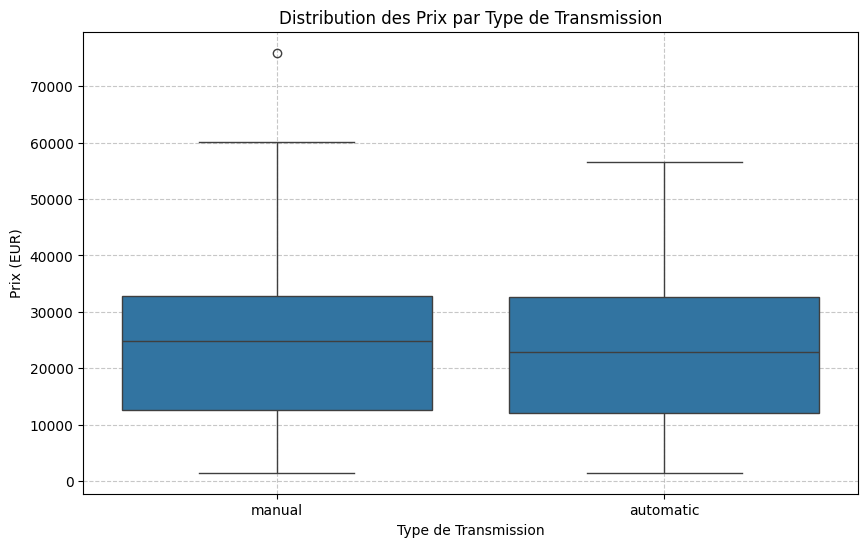

In [4]:
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

data= pd.read_csv("../Data/useCarData.csv", sep=";")
data.isnull().sum()

plt.figure(figsize=(10, 6))
sns.boxplot(x='Transmission type', y='Price (EUR)', data=data)
plt.title('Distribution des Prix par Type de Transmission')
plt.xlabel('Type de Transmission')
plt.ylabel('Prix (EUR)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# display setting
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_palette("husl")

# load data
df = pd.read_csv('../Data/useCarData.csv', sep=';', decimal=',')

# output explaratory analysis results
print("=" * 80)
print("ANALYSE EXPLORATORY USE CAR DATASET")
print("=" * 80)

print("\n1. INFORMATIONS GÉNÉRALES SUR LA BASE DE DONNÉES")
print("-" * 50)
print(f"Dimensions de la base : {df.shape[0]} lignes et {df.shape[1]} colonnes")

print("\n2. STRUCTURE DES DONNÉES")
print("-" * 50)
print(df.info())
print("\n3. STATISTIQUES DESCRIPTIVES DES VARIABLES NUMÉRIQUES")
print("-" * 50)
print(df.describe())



ANALYSE EXPLORATOIRE DES VÉHICULES D'OCCASION

1. INFORMATIONS GÉNÉRALES SUR LA BASE DE DONNÉES
--------------------------------------------------
Dimensions de la base : 100 lignes et 41 colonnes

2. STRUCTURE DES DONNÉES
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 41 columns):
 #   Column                                Non-Null Count  Dtype 
---  ------                                --------------  ----- 
 0   Brand and model                       100 non-null    object
 1   Year of manufacture                   100 non-null    int64 
 2   Mileage                               100 non-null    int64 
 3   Engine power (hp)                     100 non-null    int64 
 4   Fuel type                             100 non-null    object
 5   Transmission type                     100 non-null    object
 6   Trim level / Equipment line           100 non-null    object
 7   Vehicle condition      

['Year of manufacture', 'Mileage', 'Engine power (hp)', 'Power output (kW)', 'Engine displacement (cc)', 'Price (EUR)', 'Number of doors', 'Number of seats']

4. ANALYSE OF PRIX
--------------------------------------------------
count      100.000000
mean     23453.610000
std      14857.978389
min       1500.000000
25%      12068.750000
50%      23612.500000
75%      32723.500000
max      75938.000000
Name: Price (EUR), dtype: float64
--------------------------------------------------

4. FREQUENCY DISTRIBUTION OF PRIX
Frequenzen: [10  4  4  5  6  6  5  3  8  7  6  8  4  9  3  1  3  1  2  0  2  0  1  1
  0  0  0  0  0  1]
--------------------------------------------------

4. BIN EDGES OF PRIX 
Bin-Grenzen: [ 1500.          3981.26666667  6462.53333333  8943.8
 11425.06666667 13906.33333333 16387.6        18868.86666667
 21350.13333333 23831.4        26312.66666667 28793.93333333
 31275.2        33756.46666667 36237.73333333 38719.
 41200.26666667 43681.53333333 46162.8        48644.06

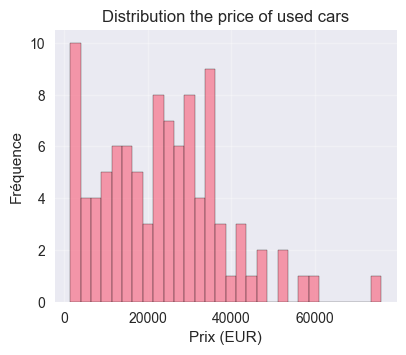

In [21]:
# Nettoyage et préparation des données
# Conversion des colonnes numériques
numeric_columns = ['Year of manufacture', 'Mileage', 'Engine power (hp)', 'Power output (kW)', 
                  'Engine displacement (cc)', 'Price (EUR)', 'Number of doors', 'Number of seats']
print(numeric_columns)

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Extraction de l'année de la date
#df['Energy consumption'] = pd.to_numeric(df['Energy consumption'].str.extract('(\d+\.?\d*)')[0], errors='coerce')

# 1. Analyse of price variable
print("\n4. ANALYSE OF PRIX")
print("-" * 50)
price_stats = df['Price (EUR)'].describe()
print(price_stats)
print("-" * 50)

print("\n4. FREQUENCY DISTRIBUTION OF PRIX")

counts, bin_edges = np.histogram(df['Price (EUR)'].dropna(), bins=30)
print("Frequenzen:", counts)
print("-" * 50)
print("\n4. BIN EDGES OF PRIX ")
print("Bin-Grenzen:", bin_edges)

# Graphique 1: Distribution des prix
plt.figure(figsize=(15, 12))

plt.subplot(3, 3, 1)
plt.hist(df['Price (EUR)'].dropna(), bins=30, edgecolor='black', alpha=0.7)
plt.title('Distribution the price of used cars')
plt.xlabel('Prix (EUR)')
plt.ylabel('Fréquence')
plt.grid(True, alpha=0.3)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, 'Audi A3'),
  Text(1, 0, 'Renault Mégane'),
  Text(2, 0, 'Opel Insignia'),
  Text(3, 0, 'Opel Astra'),
  Text(4, 0, 'Volkswagen Polo'),
  Text(5, 0, 'Toyota Auris'),
  Text(6, 0, 'Toyota Corolla'),
  Text(7, 0, 'Toyota Yaris'),
  Text(8, 0, 'Audi Q5'),
  Text(9, 0, 'Mercedes-Benz C-Class')])

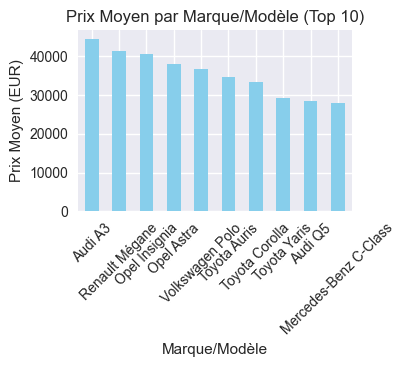

In [22]:
# Graphique 2: Prix par marque
plt.subplot(3, 3, 2)
brand_price = df.groupby('Brand and model')['Price (EUR)'].mean().sort_values(ascending=False)
brand_price.head(10).plot(kind='bar', color='skyblue')
plt.title('Prix Moyen par Marque/Modèle (Top 10)')
plt.xlabel('Marque/Modèle')
plt.ylabel('Prix Moyen (EUR)')
plt.xticks(rotation=45)

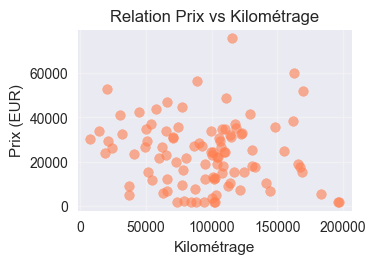

In [23]:
# Graphique 3: Prix vs Kilométrage
plt.subplot(3, 3, 3)
plt.scatter(df['Mileage'], df['Price (EUR)'], alpha=0.6, color='coral')
plt.title('Relation Prix vs Kilométrage')
plt.xlabel('Kilométrage')
plt.ylabel('Prix (EUR)')
plt.grid(True, alpha=0.3)

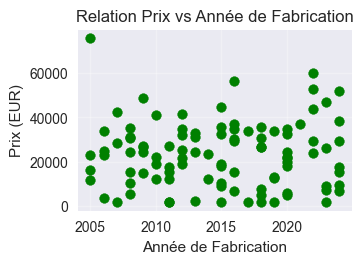

In [27]:
df[['Mileage', 'Price (EUR)']].isna().sum()

# Graphique 4: Prix vs Année de fabrication
plt.subplot(3, 3, 4)
plt.scatter(df['Year of manufacture'], df['Price (EUR)'], alpha=1.0, color='green')
plt.title('Relation Prix vs Année de Fabrication')
plt.xlabel('Année de Fabrication')
plt.ylabel('Prix (EUR)')
plt.grid(True, alpha=0.3)


(array([0, 1]), [Text(0, 0, 'Dealer'), Text(1, 0, 'Private')])

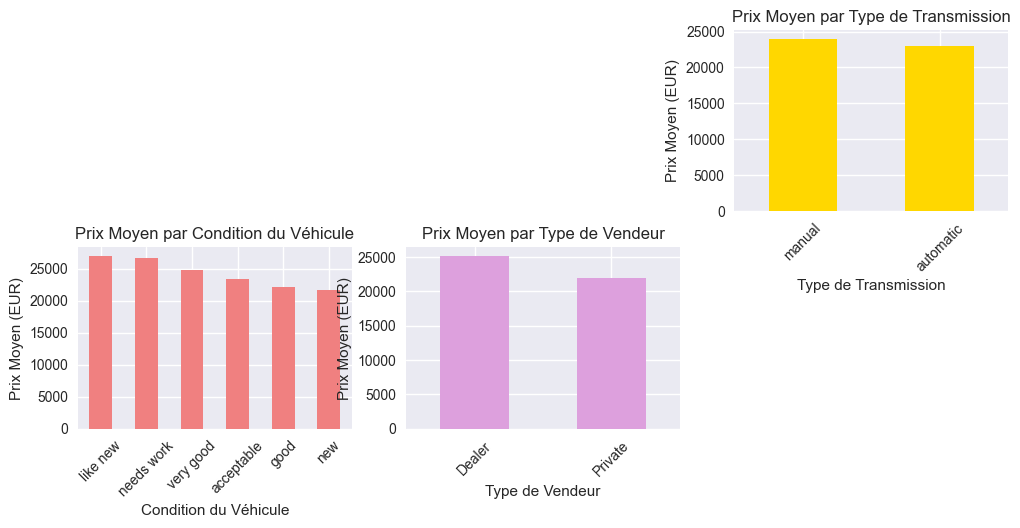

In [36]:
# Graphique 6: Prix par type de transmission
plt.subplot(3, 3, 6)
transmission_price = df.groupby('Transmission type')['Price (EUR)'].mean().sort_values(ascending=False)
transmission_price.plot(kind='bar', color='gold')
plt.title('Prix Moyen par Type de Transmission')
plt.xlabel('Type de Transmission')
plt.ylabel('Prix Moyen (EUR)')
plt.xticks(rotation=45)

# Graphique 7: Prix par condition du véhicule
plt.subplot(3, 3, 7)
condition_price = df.groupby('Vehicle condition')['Price (EUR)'].mean().sort_values(ascending=False)
condition_price.plot(kind='bar', color='lightcoral')
plt.title('Prix Moyen par Condition du Véhicule')
plt.xlabel('Condition du Véhicule')
plt.ylabel('Prix Moyen (EUR)')
plt.xticks(rotation=45)

# Graphique 8: Prix par type de vendeur
plt.subplot(3, 3, 8)
seller_price = df.groupby('Seller type')['Price (EUR)'].mean().sort_values(ascending=False)
seller_price.plot(kind='bar', color='plum')
plt.title('Prix Moyen par Type de Vendeur')
plt.xlabel('Type de Vendeur')
plt.ylabel('Prix Moyen (EUR)')
plt.xticks(rotation=45)




10. ANALYSE APPROFONDIE DES RELATIONS
--------------------------------------------------


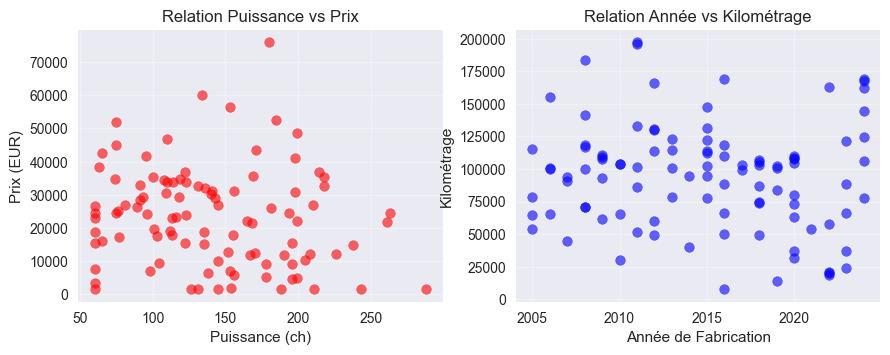

In [37]:
# 7. Analyse approfondie des relations
print("\n10. ANALYSE APPROFONDIE DES RELATIONS")
print("-" * 50)

plt.figure(figsize=(16, 12))

# Graphique 25: Relation puissance vs prix
plt.subplot(3, 3, 1)
plt.scatter(df['Engine power (hp)'], df['Price (EUR)'], alpha=0.6, color='red')
plt.title('Relation Puissance vs Prix')
plt.xlabel('Puissance (ch)')
plt.ylabel('Prix (EUR)')
plt.grid(True, alpha=0.3)

# Graphique 26: Relation année vs kilométrage
plt.subplot(3, 3, 2)
plt.scatter(df['Year of manufacture'], df['Mileage'], alpha=0.6, color='blue')
plt.title('Relation Année vs Kilométrage')
plt.xlabel('Année de Fabrication')
plt.ylabel('Kilométrage')
plt.grid(True, alpha=0.3)


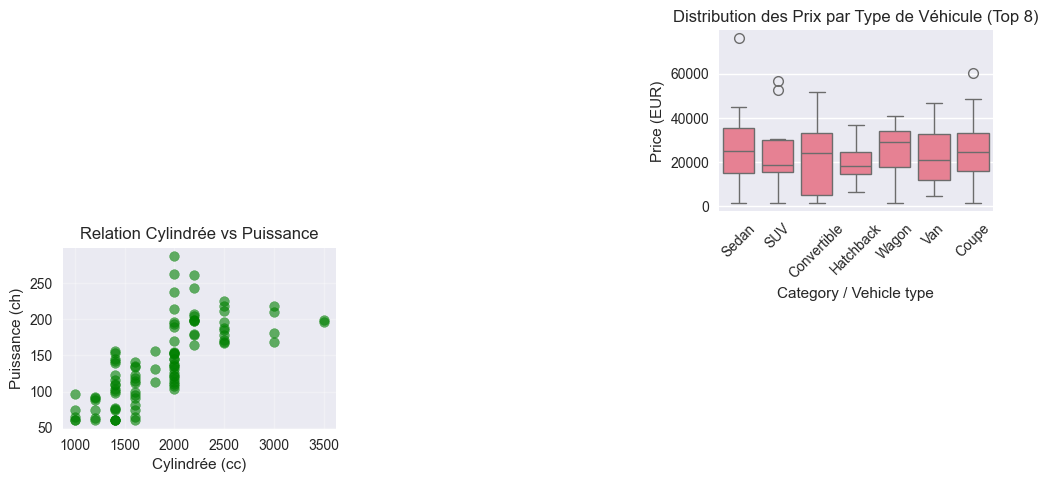

In [38]:

# Graphique 27: Boxplot prix par type de véhicule
plt.subplot(3, 3, 3)
top_categories = df['Category / Vehicle type'].value_counts().head(8).index
filtered_df = df[df['Category / Vehicle type'].isin(top_categories)]
sns.boxplot(data=filtered_df, x='Category / Vehicle type', y='Price (EUR)')
plt.title('Distribution des Prix par Type de Véhicule (Top 8)')
plt.xticks(rotation=45)

# Graphique 28: Relation cylindrée vs puissance
plt.subplot(3, 3, 4)
plt.scatter(df['Engine displacement (cc)'], df['Engine power (hp)'], alpha=0.6, color='green')
plt.title('Relation Cylindrée vs Puissance')
plt.xlabel('Cylindrée (cc)')
plt.ylabel('Puissance (ch)')
plt.grid(True, alpha=0.3)


NameError: name 'df' is not defined

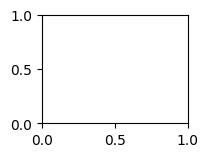

In [3]:
import matplotlib.pyplot as plt


#Graphique 29: Distribution du nombre de propriétaires
plt.subplot(3, 3, 5)
owner_counts = df['Number of previous owners'].value_counts().sort_index()
owner_counts.plot(kind='bar', color='orange')
plt.title('Distribution du Nombre de Propriétaires Précédents')
plt.xlabel('Nombre de Propriétaires')
plt.ylabel('Fréquence')

# Graphique 30: État d'inspection vs prix
plt.subplot(3, 3, 6)
inspection_price = df.groupby('Inspection status (TÜV/HU)')['Price (EUR)'].mean().sort_values(ascending=False)
inspection_price.plot(kind='bar', color='purple')
plt.title('Prix Moyen par État d\'Inspection')
plt.xlabel('État d\'Inspection')
plt.ylabel('Prix Moyen (EUR)')
plt.xticks(rotation=45)

In [ ]:

#raphique 5: Prix par type de carburant
plt.subplot(3, 3, 5)
fuel_price = df.groupby('Fuel type')['Price (EUR)'].mean().sort_values(ascending=False)
fuel_price.plot(kind='bar', color='lightgreen')
plt.title('Prix Moyen by fuel type ')
plt.xlabel('Fuel type ')
plt.ylabel('Prix Moyen (EUR)')
plt.xticks(rotation=45)